# Druk, temperatuur en energie

## Doelen
Refreshen wat we eerder hebben gedaan:
- class voor particles
- functies voor detecteren botsingen
- toelichten van een snellere manier van programmeren.

Voor een gegeven simulatie:
- een functie schrijven voor de temperatuur
- een functie schrijven voor de druk
- bovenstaande functie verbeteren door een averaging


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [2]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self, dt):
        self.r += self.v * dt # + 1/2 * a * dt**2  
    
    # Het updaten van de snelheid door zwaartekracht
    # def update_velocity(self, a, dt):
    #     """Update the particle's velocity."""
    #     self.v += a*dt
    
    # Het bepalen of er een botsing plaats vindt
    def collide_detection(self, other):
        return np.linalg.norm(self.r - other.r) < (self.R + other.R)
    
    # Harde wand
    def boxcollision(self):
        impulse = np.zeros(2)
        p_before = self.momentum.copy()


        for i in [0, 1]:
            if abs(self.r[i]) + self.R > Box_length:
                impulse[i] = 2 * self.m * abs(self.v[i])
                self.v[i] *= -1
                self.r[i] = np.sign(self.r[i]) * (Box_length - self.R)

        return impulse  # altijd positief
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [3]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
particles = []
pressure_time = []
N = 500
v_0 = 1
straal = .5
dt = 0.04

# Aanmaken van deeltjes
for i in range(N):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = (Box_length_0-straal)*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=straal)) 


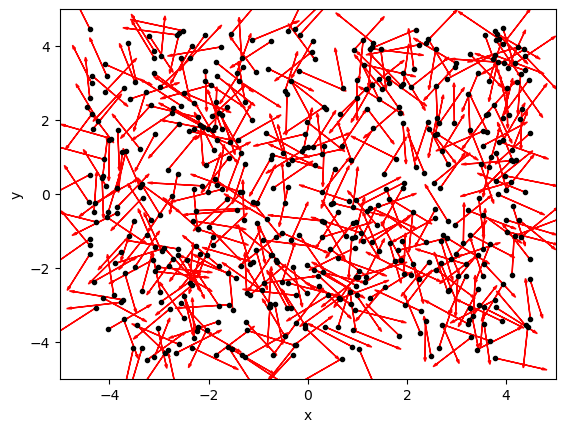

In [4]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],'k.')
    plt.arrow(particle_object.r[0],particle_object.r[1], 
              particle_object.v[0],particle_object.v[1], 
              head_width=0.05, head_length=0.1, color='red')
plt.show()


In [5]:
def handle_collisions(particles):
    ignore_list = []
    for i, p1 in enumerate(particles):
        if p1 in ignore_list:
            continue
        for j, p2 in enumerate(particles):
            if p1 is p2:
                continue
            if p1.collide_detection(p2):
                r1, r2 = p1.r, p2.r
                v1, v2 = p1.v, p2.v
                m1, m2 = p1.m, p2.m

                delta_r = r1 - r2
                delta_v = v1 - v2
                distance_squared = np.dot(delta_r, delta_r) + 1e-12  # voorkom deling door 0

                # Botsing oplossen volgens elastische botsing in 2D
                v1_new = v1 - 2 * m2 / (m1 + m2) * np.dot(delta_v, delta_r) / distance_squared * delta_r
                v2_new = v2 - 2 * m1 / (m1 + m2) * np.dot(-delta_v, -delta_r) / distance_squared * (-delta_r)

                p1.v = v1_new
                p2.v = v2_new

                ignore_list.append(p2)

Laten we kijken naar de energie distributie:

Triggert een error. Die error wordt veroorzaakt doordat er te weinig variatie is in de data om een histogram te maken.

```{exercise}
Hadden we dat kunnen verwachten? Waarom?
```

```{exercise}
Wat verwacht je van de energie distributie na het draaien van de simulatie?
```

In [6]:
for i in range(100):
    total_impulse = np.zeros(2)    
    for p in particles:
        p.update_position(dt)    # Update positie
        total_impulse += p.boxcollision()
                 # Wandbotsing werkt per deeltje
        
        p.kin_energy             # Energie 
    pressure_time.append(np.sum(total_impulse))
    handle_collisions(particles)


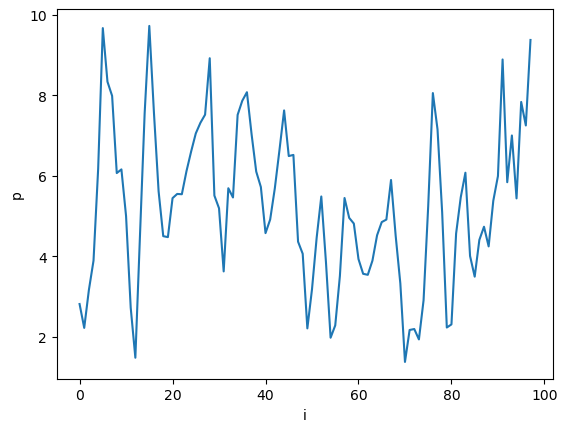

In [10]:
# plotten van druk als functie van tijd

pressure_time = np.array(pressure_time)
pressure = (pressure_time[0:-2]+pressure_time[1:-1]+pressure_time[2:])/3

plt.figure()
plt.plot(pressure)
plt.xlabel('i')
plt.ylabel('p')
plt.show()

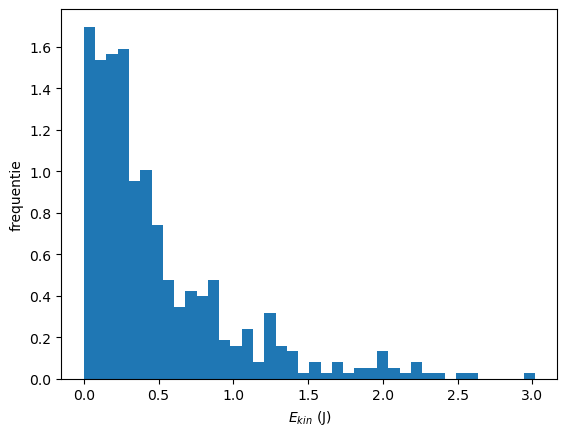

In [8]:
energies = [p.kin_energy for p in particles]

plt.figure()
plt.xlabel('$E_{kin}$ (J)')
plt.ylabel('frequentie')

plt.hist(energies,bins=40,density='True')

plt.show()

## Temperatuur

iets als gem. kin. e

schrijf een functie die de temperatuur bepaald op basis van gemiddelde kinetische.


    @property
    def temperature(self):
        en = 0.0
        for atom in self.atoms:
            en += 0.5 * atom.mass * np.dot(atom.velocity, atom.velocity)
        return en / len(self.atoms)

# Druk

botsing met wand, dan impuls verandering $p=2mv$

som van botsingen met wand gedeeld door opp van de wand (4 boxsize)

dus dan gaan werken in de boxcollision:
